# F1 Driver Performance Index
### A data driven approach to the greatest F1 driver of all time

## Introduction

If you have ever spent time in any Formula 1 community, you must have heard of the debate of who is the greatest F1 driver of all time. Is it the Hamilton? With his record breaking statistics in nearly every major category? Or Schumacher showing his dominace in Ferrari for years? Or Senna with his raw talent and speed? Fangio with his five titles in an era where racing was still considered life threatening? Or most recently Max Verstappen, showing his abosolute dominace with the quickest title win in history?

The problem with all of these arguements is that they're usually based on cherry picked statistics, nostalgia, recency bias, or even pure vibes. Someone throws out the term "most wins" and someone else counters with "yeah but [INSERT CONSTRUCTOR HERE]'s car was so dominate". 

I wanted to try something different than just using the usual statistics for greatness. Instead of arguing about individual stats, I wanted to build a composite index that incorporates wins, qualifying results, teammate battles, car performance, consistency, and career longevity all at once. Something similar to baseball's WAR or basketballs PER, but for Formula 1 specifically

That is what I am trying to create with the Driver Performance Index (DPI). It's a composite score built from 17 indicators, adjusted for era differences, weighted by statistical methods, and designed to answer the question: Who is the greatest of all time? 

A few disclaimers before we get started: 
- **This is not a definitive answer.** Any composite index involces subjective choices about what to measure and how to weight it. I'll be transparent about every choice I made and how sensitive the results are to those choices. 
- **The car matters enormously in F1** I've build in several adjustments for car performance, but no statistical method can perfectly separate driver from machine. This is a major challenege in analytics for F1.
- **Data availability varies by era** Qualifying data only goes back to 1994. Fastest lap rankings aren't available before the 2000s. I try to handle these gaps with Bayesian shrinkage rather than excluding older drivers entirely. 
- **This is not final** This is by no means a final analyses. I would like to treat this has a living analysis to update as I get more data. I would also love reccomendations on statistical methods or any ideas from my peers. 

I started this project as a way to combine two things I love, data and Formula 1. I admit, I came into F1 as a Drive to Survive fan, but ever since I have been obsessed with it. I wake up early or stay up late to watch all the gran prixs, qualifying sessions, and free practices practice sessions. I even started to follow f2 drivers to see who the new talent being promoted into F1. I admit, I am and avid fan, and not an expert by any means when it comes to engineering cars or knowing absoluitly every nuiance of F1, but I am trying to learn, and I still have so much more to learn! If you're reading this, I hope you enjoy the methodology and the results. 

Lets get to it!

## Methodology Overview
The DPI is built in layers: 

1. **17 raw indicators** are calculated for each driver in each season (e.g., win rate, teammate head-to-heads, consistency)
2. **Z-score standardization within each season** adjusted for era - a driver is compared to their current peers, not to drivers 50 years apart
3. **Bayesian shrinkage** handles small sample sizes. so a driver with 3 races isn't treated the same as a driver with 20 races
4. **Indicators are combined** into a single season DPI using two methods: PCA (data driven weights) and expert weights (theory-driven). I will compare both. 
5. **Season DPIs are aggregated** into a career score using a Bayesian career estimate (primary) and area under the curve (secondary)
6. **Bootstrap confidence intervals** quantify how certain we are about each driver's ranking

Note: I have chosen the expert weights based off of research. I am open to opionons on weighting differences and changes. 

The following sections will walk through each step with code and explanation.

In [47]:
import os
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns
import pg8000

# Plot styling
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

## Data Source
We pulled our data from the [Jolpica F1 API](http://api.jolpi.ca/ergast/f1/), the open-source successor to the Ergast Motor Racing Database. The dataset covers every F1 season from 1950 to 2025, including race results, qualifying times, and championship standings. 

The raw data was cleaned and typed in our [00_data_cleaning.ipynb](00_data_cleaning.ipynb) notebook. The clean data lives in a local PostgreSQL database across three tables:
- **f1_results** — 25,873 race results (one row per driver per race)
- **f1_qualifying** — 10,973 qualifying results (1994 onward)
- **f1_standings** — 3,095 season-end championship standings

Database connection details can be found <here>.

In [48]:
def load_env(path: str) -> None:
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#") or "=" not in line:
                continue
            k,v = line.split("=", 1)
            os.environ.setdefault(k.strip(), v.strip())

def get_conn():
    return pg8000.connect(
        host=os.environ["DB_HOST"],
        port=int(os.environ["DB_PORT"]),
        database=os.environ["DB_NAME"],
        user=os.environ["DB_USER"],
        password=os.environ["DB_PASSWORD"],
    )

# Notebook is in f1/notebooks/ — .env lives one level up at f1/.env
load_env(os.path.join(os.getcwd(), "..", ".env"))
conn = get_conn()

# Load our cleaned tables
df_results = pd.read_sql("SELECT * FROM sports_clean.f1_results", conn)
df_qualifying = pd.read_sql("SELECT * FROM sports_clean.f1_qualifying", conn)
df_standings = pd.read_sql("SELECT * FROM sports_clean.f1_standings", conn)

print(f"Results:    {len(df_results):,} rows")
print(f"Qualifying: {len(df_qualifying):,} rows")
print(f"Standings:  {len(df_standings):,} rows")

Results:    25,873 rows
Qualifying: 10,973 rows
Standings:  3,095 rows


## Indicator 1: Win Rate

Win rate is the arguably the most intuitive measure for a drivers greatness. That is, how often does a single driver win? That said, raw wins aren't a fair metric across eras, regulations change, number of races have increased, and a single construtor dominace has become more prevelant in recent eras. For example, a drive from the 1950s only had 7 races per season to win, while now in the modern era we have 24 races, not even including sprint races. Because of that we will use the *rate* (wins divided by races) instead of the raw count alone

Also, we want to account for reliability issues, so we will adjust the denominator using our DNF classification weights. If a drivers engine blows up, that shouldn't be on the driver. On the other hand, if the drive too aggressivly and cause their car to launch into the barrier, that should be on them. For that reason we give weights to each classification of DNFs to make sure we measure each driver fairly. This prevents drivers from unreliable eras (1950s-80s) from being unfaurly penalized. 

**Formula:** 'win_rate = total_wins / sum(race_weights)'

this gives us a per-career rate, but we'll calculated it per-season first since that's our building block. The z-score standardization within each season should handle the era comparison 

In [49]:
def compute_win_rate(df: pd.DataFrame) -> pd.DataFrame:   
    """
    Calculates Win Rate for a driver

    win_rate = total_wins/sum(race_weights)
    """
    df = df.copy()
    
    # Flag each results as a win (1) or not (0)
    df['is_win'] = (df['finish_position'] == 1).astype(int)

    # Group by driver and season, then calculated adjusted win rate
    win_rate = df.groupby(['driver_id', 'season']).agg(
        wins=('is_win', 'sum'),
        race_weight_sum=('race_weight', 'sum'),
        races_entered=('is_win', 'count'),
        driver_last_name=('driver_last_name', 'first')
    ).reset_index()

    win_rate['win_rate'] = win_rate['wins'] / win_rate['race_weight_sum']

    return win_rate

win_rate = compute_win_rate(df_results)


# Look at the top win rates (min 5 races to filter)
print("Highest single-season win rates (min 5 races):")
top_win = win_rate[win_rate['races_entered'] >= 5].nlargest(10, 'win_rate')
print(top_win[['driver_last_name', 'season', 'wins', 'races_entered', 'win_rate']].to_string(index=False))

Highest single-season win rates (min 5 races):
driver_last_name  season  wins  races_entered  win_rate
          Ascari    1952     6              7  0.923077
           Clark    1965     6              9  0.888889
      Verstappen    2023    19             22  0.863636
          Fangio    1955     4              6  0.761905
           Clark    1963     7             10  0.756757
          Fangio    1950     3              7  0.750000
          Fangio    1954     6              8  0.750000
         Brabham    1960     5              8  0.740741
           Rindt    1970     5             10  0.740741
      Schumacher    2004    13             18  0.732394


## Indicator 2: Podium Rate

This indicator is similar to win rate, but we are counting top 3 finishes. Podiums capture consistent front-running performance. A driver who consistently finishes P2 or P3 is still performaing at an elite level, even if they aren't actually winning every race. 

We are using the same DNF adjusted denominator as win rate for this indicator.

**Formula:** podium_rate = top_3_finishes / sum(race_weights)

In [50]:
def calculate_podium_rate(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calculates a drivers podium rate

    podium_rate = top_3_finishes/sum(race_weights)
    """
    df = df.copy()     
    df['is_podium'] = (df['finish_position'] <= 3).astype(int)

    podium_rate = df.groupby(['driver_id', 'season']).agg(
        podiums=('is_podium', 'sum'),
        race_weight_sum=('race_weight', 'sum'),
        races_entered=('is_podium', 'count'),
        driver_last_name=('driver_last_name', 'first')
    ).reset_index()

    podium_rate['podium_rate'] = podium_rate['podiums'] / podium_rate['race_weight_sum']

    return podium_rate

podium_rate = calculate_podium_rate(df_results)

print("Top 10 single-season podium rates (min 5 races):")
top = podium_rate[podium_rate['races_entered'] >=5].nlargest(10, 'podium_rate')
print(top[['driver_last_name', 'season', 'podiums', 'races_entered', 'podium_rate']].to_string(index=False))

Top 10 single-season podium rates (min 5 races):
driver_last_name  season  podiums  races_entered  podium_rate
      Schumacher    2002       17             17     1.000000
           Clark    1963        9             10     0.972973
          Fangio    1957        6              7     0.960000
      Verstappen    2023       21             22     0.954545
          Fangio    1955        5              6     0.952381
        González    1951        5              6     0.952381
           Prost    1988       14             16     0.949153
        Hamilton    2014       16             19     0.941176
        Hamilton    2015       17             19     0.931507
          Ascari    1952        6              7     0.923077


## Indicator 3: Points Per Race - Era Normalized

 Calculating raw points is meaningless across the different eras because of the point system changes as well as the number of races having increased. My solution to this is to double normalize. 

 So first we wll convert each race's points to a **percentage of maximum possible** for that race. This will hopefully remove the scale sifference between point systems. Next, we will calculate the **z-score within the season** to adjust for era competitveness. This part will happen a bit later in the code

 **Formula:** points_pct = points_scored / max_points_that_race

In [ ]:
def calculate_ppr(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calculates a drivers percentile for points per race

    points_pct = points_scored/max_points_that_race
    """
    df = df.copy()

    # Find max points scored in each race (i.e. winners points)
    race_max_points = df.groupby(['season', 'round'])['points'].max().reset_index()
    race_max_points.columns = ['season', 'round', 'max_points']

    # Merge the max_points back into the results
    df = df.merge(race_max_points, on=['season', 'round'], how='left')

    # Calculate percentage of max points
    # Note: We will want to avoid div by 0 where max_points = 0 - these are rare edge cases
    df['points_pct'] = np.where(
        df['max_points'] > 0,
        df['points'] / df['max_points'],
        0
    )

    # Aggregate per driver per season weighted by race_weight
    points_per_race = df.groupby(['driver_id', 'season']).agg(
        total_points_pct=('points_pct', 'sum'),
        race_weight_sum=('race_weight', 'sum'),
        races_entered=('points_pct', 'count'),
        driver_last_name=('driver_last_name', 'first')
    ).reset_index()

    points_per_race['points_per_race'] = points_per_race['total_points_pct'] / points_per_race['race_weight_sum']

    return points_per_race

points_per_race = calculate_ppr(df_results)

print('Top 10 single season points per race (min 5 races entered):')
top = points_per_race[points_per_race['races_entered'] >= 5].nlargest(10, 'points_per_race')
print(top[['driver_last_name', 'season', 'races_entered', 'points_per_race']].to_string(index=False))


## Indicator 4: Fastest Lap Performance

This indicator looks at how a driver's race pace compares to the field. In the data we have has 'fastest_lap_rank', which is the driver's fastest lap ranked against all other drivers for that race. Rank 1 means they set the fastest lap. 

We are going to convert rank to a percentile so it's comparable across different field sizes. We weight this indicator lower than win rate and podium rate because fastest laps are sometimes influenced by stratagy. that is to say, sometimes a team will pit one of their drivers for softs to steal the fastest lap on the last lap of the race, especially when the fastest lap was worth bonus points. 

**Formula:** fastest_lap_pct = 1 - (rank - 1) / (field_size - 1)

Note: Fastest lap data is only available from approximately 2004 onward. Earlier season will have missing valuyes, which the Bayesian shrinkage step will handle later

In [62]:

# Calculate field size per race directly in df_results
# We will use this variable in later calculatoins too
field_size = df_results.groupby(['season', 'round']).size().reset_index(name='field_size')
df_results = df_results.merge(field_size, on=['season', 'round'], how='left')

def calculate_flp(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calculates Fastest Lap Performance for a driver

    fastest_lap_pct = 1-(rank-1)/(field_size-1)
    """
    df = df.copy()

    # Convert fastest lap rank to a percentile (1 = best, 0 = worst)
    df['fastest_lap_pct'] = np.where(
        df['fastest_lap_rank'].notna() & (df['field_size'] > 1),
        1 - (df['fastest_lap_rank'] - 1) / (df['field_size'] - 1),
        np.nan
    )

    # Aggregate per driver per season
    fl_perf = df[df['fastest_lap_pct'].notna()].groupby(['driver_id', 'season']).agg(
        avg_fl_pct=('fastest_lap_pct', 'mean'),
        fl_races=('fastest_lap_pct', 'count'),
        driver_last_name=('driver_last_name', 'first')
    ).reset_index()

    fl_perf.rename(columns={'avg_fl_pct': 'fastest_lap_performance'}, inplace=True)

    return fl_perf

fl_perf = calculate_flp(df_results)

print("Top 10 single-season fastest lap performance (min 5 races entered):")
top = fl_perf[fl_perf['fl_races'] >= 5].nlargest(10, 'fastest_lap_performance')
print(top[['driver_last_name', 'season', 'fl_races', 'fastest_lap_performance']].to_string(index=False))

Top 10 single-season fastest lap performance (min 5 races entered):
driver_last_name  season  fl_races  fastest_lap_performance
      Schumacher    2004        18                 0.970760
       Räikkönen    2008        18                 0.952242
       Räikkönen    2005        18                 0.940144
      Schumacher    2006        18                 0.931217
      Verstappen    2023        22                 0.923445
          Alonso    2007        17                 0.921569
        Hamilton    2015        19                 0.916898
        Hamilton    2020        16                 0.914474
       Räikkönen    2007        17                 0.901961
      Verstappen    2021        20                 0.900000


## Indicator 5: Teammate H2H - Qualifying

Teammate comparison is arguably one of the most important indicators in this index because it directly controls for car performance between teams. There are minor nuances (Like the No 1 drivers recieving upgrades first), but overall both drivers generally have the same machinery. 

This indicator is for qualifying specifically. We will look a what percentage of the time did a driver out qualify their teammate. In races where a team had 3+ driver (usually pre-1986), we do all pairwise comparisons and use the win percentage so that 2-car and 3 car teams are on equal footing. 

**Formula:** quali_h2h = count(qualified ahead of teammate) / count(pairwise comparisons)

In [ ]:
def calculate_h2h_quali(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calculates head to head qualifying comparisons for each driver

    quali_h2h = count(qualified ahead of teammate)/count(pairwise comparisons)
    """
    df = df.copy()

    quali_h2h_records = []
    for (season, rnd), group in df.groupby(['season', 'round']):
        # Group drivers by constructor within this race
        for constructor, team_group in group.groupby('constructor_id'):
            drivers = team_group[['driver_id', 'quali_position']].values.tolist()

            # Skip if only one driver
            if len(drivers) < 2:
                continue

            # All pairwise comparisons
            for i in range(len(drivers)):
                for j in range(len(drivers)):
                    if i == j:
                        continue
                    driver_a, pos_a = drivers[i]
                    driver_b, pos_b = drivers[j]

                    # Lower position number = better qualifying
                    if pd.notna(pos_a) and pd.notna(pos_b):
                        quali_h2h_records.append({
                            'season': season,
                            'round': rnd,
                            'driver_id': driver_a,
                            'teammate_id': driver_b,
                            'constructor_id': constructor,
                            'beat_teammate': 1 if pos_a < pos_b else 0
                        })

    df_quali_h2h = pd.DataFrame(quali_h2h_records)
    print(f'Total pairwise qualifying comparisons: {len(df_quali_h2h):,}')

    # Aggregate to driver-season level
    quali_h2h = df_quali_h2h.groupby(['driver_id', 'season']).agg(
        quali_wins=('beat_teammate', 'sum'),
        quali_comparisons=('beat_teammate', 'count')
    ).reset_index()

    quali_h2h['quali_h2h_rate'] = quali_h2h['quali_wins'] / quali_h2h['quali_comparisons']

    # Build name lookup from the df parameter (not a global)
    name_lookup = df[['driver_id', 'driver_last_name']].drop_duplicates()
    quali_h2h = quali_h2h.merge(name_lookup, on='driver_id', how='left')

    return quali_h2h

quali_h2h = calculate_h2h_quali(df_qualifying)

print('\nTop 10 qualifying H2H rates (min 10 comparisons):')
top = quali_h2h[quali_h2h['quali_comparisons'] >= 10].nlargest(10, 'quali_h2h_rate')
print(top[['driver_last_name', 'season', 'quali_wins', 'quali_comparisons', 'quali_h2h_rate']].to_string(index=False))


## Indicator 6: Teammate H2H - Race

This indicator has the same concept as the qualifying H2H, but based on race finishing position instead. The key difference, we apply our DNF weighting to each comparison. This is because if a drivers engine blows up and the other driver finishes, technically one driver "beat" the other. For that reasons we assign those comparisons a 0.25 weight. On the other hand, if a driver DNFs because of a driver error (like crashing into a barrier), we assign a weight of 0.75. If both drivers finish, then the weight is 1.0 (full weight).

**Formula:** race_h2h = weighted_wins / weighted_comparisons

Note: I recognize a driver crashing could be caused by other driver errors. That is why we assign a 0.75 weight. Unfortunatly we do not currently have data showing who is at fault for crashes. I would like to create a dataset as a separate project showing this data and combining it into our DPI

In [ ]:
def calculate_h2h_race(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calculates head to head race comparisons for all drivers

    race_h2h = weighted_wins/weighted_comparisons
    """
    df = df.copy()

    # Build name lookup from the df parameter (not a global)
    name_lookup = df[['driver_id', 'driver_last_name']].drop_duplicates()

    # Build teammate race comparisons with DNF weighting
    race_h2h_records = []

    for (season, rnd), group in df.groupby(['season', 'round']):
        for constructor, team_group in group.groupby('constructor_id'):
            drivers = team_group[['driver_id', 'finish_position', 'race_weight']].values.tolist()

            if len(drivers) < 2:
                continue

            for i in range(len(drivers)):
                for j in range(len(drivers)):
                    if i == j:
                        continue
                    driver_a, pos_a, weight_a = drivers[i]
                    driver_b, pos_b, weight_b = drivers[j]

                    if pd.notna(pos_a) and pd.notna(pos_b):
                        # The comparison weight is the minimum of both drivers' weights
                        # If either had a mechanical DNF, the comparison is less reliable
                        comparison_weight = min(weight_a, weight_b)

                        race_h2h_records.append({
                            'season': season,
                            'round': rnd,
                            'driver_id': driver_a,
                            'teammate_id': driver_b,
                            'constructor_id': constructor,
                            'beat_teammate': 1 if pos_a < pos_b else 0,
                            'comparison_weight': comparison_weight
                        })

    df_race_h2h = pd.DataFrame(race_h2h_records)
    print(f'Total pairwise race comparisons: {len(df_race_h2h):,}')

    # Weighted aggregation
    race_h2h = df_race_h2h.groupby(['driver_id', 'season']).apply(
        lambda g: pd.Series({
            'race_h2h_wins': (g['beat_teammate'] * g['comparison_weight']).sum(),
            'race_h2h_weight_sum': g['comparison_weight'].sum(),
        })
    ).reset_index()

    race_h2h['race_h2h_rate'] = race_h2h['race_h2h_wins'] / race_h2h['race_h2h_weight_sum']
    race_h2h = race_h2h.merge(name_lookup, on='driver_id', how='left')

    return race_h2h

race_h2h = calculate_h2h_race(df_results)

print('\nTop 10 race H2H rates (min 10 weighted comparisons):')
top = race_h2h[race_h2h['race_h2h_weight_sum'] >= 10].nlargest(10, 'race_h2h_rate')
print(top[['driver_last_name', 'season', 'race_h2h_rate']].to_string(index=False))


## Indicator 7: WAR - Value Over Replacement

This is probably our most complicated and anlytically important indicator. the WAR measures how much a driver outperforms or underperforms relative to where their car "should" finish, using teammate performance as trhe baseline. 

We use a **leave-one-out** approach: the constructor's expected performance is calculated from all teammates' results (excluding the driver being evaluated). This prevents a dominat driver (like Verstapin over Perez in 2023) from inflating their baseline.

The metric is finishing percentile (adjusted for field size), not the raw position. 

**Formula:** WAR = driver_avg_finish_pct - teammate_avg_finish_pct

In [ ]:
def calculate_war(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calculates WAR (Win Above Replacement) for each driver-season.
    Measures a driver's finish percentile vs their teammate's,
    isolating driver contribution from car quality.

    war = driver_avg_finish_pct - teammate_avg_finish_pct
    """
    df = df.copy()

    # Build name lookup from the df parameter (not a global)
    name_lookup = df[['driver_id', 'driver_last_name']].drop_duplicates()

    # Calculate finishing percentile for each result
    # 1 = finished first, 0 = finished last
    df['finish_pct'] = np.where(
        df['field_size'] > 1,
        1 - (df['finish_position'] - 1) / (df['field_size'] - 1),
        0.5
    )

    # For each driver-season, calculate their avg finish pct
    # AND the leave-one-out teammate avg finish pct
    war_records = []

    for (season), season_group in df.groupby(['season']):
        for (driver_id, constructor_id), driver_group in season_group.groupby(['driver_id', 'constructor_id']):
            driver_avg = driver_group['finish_pct'].mean()

            # Find teammates: same constructor, same season, different driver
            teammates = season_group[
                (season_group['constructor_id'] == constructor_id) &
                (season_group['driver_id'] != driver_id)
            ]

            if len(teammates) == 0:
                continue

            teammate_avg = teammates['finish_pct'].mean()

            war_records.append({
                'driver_id': driver_id,
                'season': season,
                'driver_avg_finish_pct': driver_avg,
                'teammate_avg_finish_pct': teammate_avg,
                'war': driver_avg - teammate_avg,
                'races': len(driver_group)
            })

    df_war = pd.DataFrame(war_records)
    df_war = df_war.merge(name_lookup, on='driver_id', how='left')

    return df_war

df_war = calculate_war(df_results)

print('Top 10 WAR seasons (min 5 races):')
top = df_war[df_war['races'] >= 5].nlargest(10, 'war')
print(top[['driver_last_name', 'season', 'war', 'races']].to_string(index=False))


## Indicator 8: Mechanical DNF Finish Estimate (Car Adjusted)

When a driver retires from a race due to mechanical failure, they get classified near the back when in reality they may have been contending for a podium. This indicator uses a linear regression model to estimate where they *would have* finished. We will train the model on completed races by predicting final finish position from grid position, constructor season strength, and field size. Then we will apply it to the mechanical DNFs to get an estimated finish. 

**Why linear regression?** I though this would be the most simple and interperatable way to clearly explain coefficients. Grid position is the strongest predictorm with constructor strength as a secondary factor. We will check the R squared to see how well it fits. If it doesnt fit well then we will upgrade to a more complex model, but I figured this is a good starting point

In [34]:
# Calculate constructor season average (for the model feature)
constructor_avg = df_results.groupby(['season', 'constructor_id'])['finish_position'].mean().reset_index()
constructor_avg.columns = ['season', 'constructor_id', 'constructor_season_avg']
df_results = df_results.merge(constructor_avg, on=['season', 'constructor_id'], how='left')

# Calculate laps completed as percentage of total race laps
race_total_laps = df_results.groupby(['season', 'round'])['laps_completed'].max().reset_index()
race_total_laps.columns = ['season', 'round', 'total_race_laps']
df_results = df_results.merge(race_total_laps, on=['season', 'round'], how='left')

df_results['laps_pct'] = np.where(
    df_results['total_race_laps'] > 0,
    df_results['laps_completed'] / df_results['total_race_laps'],
    0
)

# Split into training data (completed races) and prediction data (mechanical DNFs)
completed = df_results[df_results['race_weight'] >= 0.5].dropna(
    subset=['grid_position', 'constructor_season_avg', 'field_size', 'finish_position']
)
mechanical_dnf = df_results[df_results['race_weight'] == 0.25].dropna(
    subset=['grid_position', 'constructor_season_avg', 'field_size']
)

# Train the model
from sklearn.model_selection import train_test_split

features = ['grid_position', 'constructor_season_avg', 'field_size']

# X are our input variables (Grid Position, Constructor Season Avg, and Field Size), y is what we are predicting
X = completed[features]
y = completed['finish_position']

# We need to split the dataset for training so the model doesnt just memorize the data
# Split: 80% training, 20% held
# random_state=42 for reproductability
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training rows: {len(X_train):,}")
print(f"Test Rows: {len(X_test):,}")

model = LinearRegression()
model.fit(X_train, y_train)

print("Linear Regression Results:")
print(f"  R² score: {model.score(X_train, y_train):.3f}")
print(f"  Coefficients:")
for feat, coef in zip(features, model.coef_):
    print(f"    {feat}: {coef:.4f}")
print(f"  Intercept: {model.intercept_:.4f}")

# Predict estimated finishes for mechanical DNFs
if len(mechanical_dnf) > 0:
    X_pred = mechanical_dnf[features]
    mechanical_dnf = mechanical_dnf.copy()
    mechanical_dnf['estimated_finish'] = model.predict(X_pred)
    
    # Clip predictions to valid range (1 to field_size)
    mechanical_dnf['estimated_finish'] = mechanical_dnf['estimated_finish'].clip(
        lower=1, 
        upper=mechanical_dnf['field_size']
    )
    
    # Weight confidence by laps completed percentage
    mechanical_dnf['estimate_confidence'] = mechanical_dnf['laps_pct']

print(f"\nMechanical DNFs with estimates: {len(mechanical_dnf):,}")
print(f"\nSample estimates:")
sample = mechanical_dnf[['driver_last_name', 'season', 'race_name', 'grid_position', 
                          'estimated_finish', 'estimate_confidence']].head(10)
print(sample.to_string(index=False))

Training rows: 15,633
Test Rows: 3,909
Linear Regression Results:
  R² score: 0.320
  Coefficients:
    grid_position: 0.1681
    constructor_season_avg: 0.7844
    field_size: -0.0431
  Intercept: 0.0952

Mechanical DNFs with estimates: 6,265

Sample estimates:
driver_last_name  season          race_name  grid_position  estimated_finish  estimate_confidence
          Fangio    1950 British Grand Prix              3          4.670255             0.885714
          Murray    1950 British Grand Prix             18         12.595221             0.628571
        Crossley    1950 British Grand Prix             17         11.896707             0.614286
  de Graffenried    1950 British Grand Prix              8         10.913853             0.514286
          Chiron    1950 British Grand Prix             11         11.418263             0.371429
          Martin    1950 British Grand Prix              7          8.081316             0.114286
            Rolt    1950 British Grand Prix        

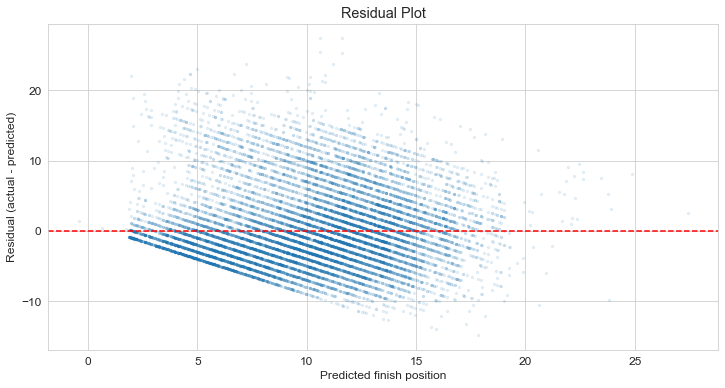

In [35]:
predicted = model.predict(X_train)
residuals = y_train - predicted

plt.scatter(predicted, residuals, alpha=0.1, s=5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted finish position')
plt.ylabel('Residual (actual - predicted)')
plt.title('Residual Plot')
plt.show()

## Linear Model Results 

The linear model returned with a R squared value of .322 which is relativly lower than what we are looking for. Looking at the graphed risidual points we can see that the modle is more concentrated in the bottom left, meaning tha it is having a hard time predicting the front runners. Ultimatly we want our R squared value to be above 0.6, but if we can get it above 0.5 it may still be usable as an indicator. Below we are upgrading the modle to a Polynomial model to see if that helps with our R squared value

In [38]:
from sklearn.preprocessing import PolynomialFeatures

# Add squared terms and interactions
# grid² captures the non-linear relationship (front of grid matters more)
# grid × constructor_avg captures "good driver in good car" effect
features_expanded = ['grid_position', 'constructor_season_avg', 'field_size']
X_train_base = X_train[features_expanded]

poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)
X_train_poly = poly.fit_transform(X_train_base)
X_test_poly = poly.transform(X_test)

model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)

print(f"Original R²:   {model.score(X_test, y_test):.3f}")
print(f"Polynomial R²: {model_poly.score(X_test_poly, y_test):.3f}")

Original R²:   0.329
Polynomial R²: 0.342


## Polynomial Model Results

Unfortunatly the polynomial modle did not fair much better than the linear model, giving us just a little be more of the explain variance. We will move on to a more complicated model, the Random Forest Regressor. This modle is slightly different, instead of fitting one line through the model, this model build multiple decisions trees that each learn a different set of rules. It then takes all those predictoins and averages them to create the final prediction

In [39]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_test, y_test)

print(f"Original Linear R²:    {model.score(X_test, y_test):.3f}")
print(f"Polynomial Linear R²:  {model_poly.score(X_test_poly, y_test):.3f}")
print(f"Random Forest R²:      {rf_model.score(X_test, y_test):.3f}")

# Feature importance
print("\nFeature importance:")
for feat, imp in sorted(zip(features, rf_model.feature_importances_), key=lambda x: x[1], reverse=True):
    print(f"  {feat}: {imp:.3f}")

Original Linear R²:    0.329
Polynomial Linear R²:  0.342
Random Forest R²:      0.425

Feature importance:
  constructor_season_avg: 0.748
  grid_position: 0.206
  field_size: 0.046


## Random Forest Model Results

So the Random Forest test came back with a R² of 0.425, which is our best performing model, but it still is below the 0.5 threshold we wanted to confidently determine DNF finishing positions. One thing I did want to note at the end of the print out is that the constructor strength actually accounts for 74.8% of the feature importance, meaning that the finishing positions can be largely determined by how good the drivers car was... which makes sense since we have seen races where a driver will qualify out of position to eventually go win the race or get on the podium with a top teams car.

This also feeds into our narative a little too, since the remaining variance (the unexplained parts) is precisely what we are trying to capture in creating this DPI. That is the missing varince could be made up of driver skills, like tyre management, stratagy calls, wet weather driving skill, etc. 

## Indicator 8 (was 9): Field Dominance - Winning Margin

This indicator measures *how much* a driver dominated, not just wheter they won. For race winners, its the time gap to P2 in seconds. for non-winners, its their gap to the winner (a negative number). Lapped drivers get an estimated gap based on average lap time multiplied by laps behind. This one I was a little hesitant to add a first because you could argue it could be atributed to the car more than the driver. Because of that we have given this a smaller weight

**Note:** This indicator uses the finish_time_ms field, which is only available for drivers on the lead lap.

In [ ]:
def calculate_field_dominance(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calculates a driver's winning margin (for winners) or gap to winner
    (for non-winners), then averages across a season.

    dominance_score = winning_margin_sec (winner) or -gap_to_winner_sec (others)
    """
    df = df.copy()

    # Get the winner's time in each race
    winner_times = df[df['finish_position'] == 1][
        ['season', 'round', 'finish_time_ms']
    ].rename(columns={'finish_time_ms': 'winner_time_ms'})
    df = df.merge(winner_times, on=['season', 'round'], how='left')

    # Calculate gap to winner in seconds
    df['gap_to_winner_sec'] = np.where(
        df['finish_time_ms'].notna() & df['winner_time_ms'].notna(),
        (df['finish_time_ms'] - df['winner_time_ms']) / 1000,
        np.nan
    )

    # For the winner, get gap to P2 (positive = more dominant)
    p2_times = df[df['finish_position'] == 2][
        ['season', 'round', 'finish_time_ms']
    ].rename(columns={'finish_time_ms': 'p2_time_ms'})
    df = df.merge(p2_times, on=['season', 'round'], how='left')

    df['winning_margin_sec'] = np.where(
        df['finish_position'] == 1,
        np.where(
            df['p2_time_ms'].notna() & df['winner_time_ms'].notna(),
            (df['p2_time_ms'] - df['winner_time_ms']) / 1000,
            np.nan
        ),
        np.nan
    )

    # For lapped drivers, estimate gap using avg lap time x laps behind
    df['avg_lap_time_ms'] = np.where(
        df['total_race_laps'] > 0,
        df['winner_time_ms'] / df['total_race_laps'],
        np.nan
    )
    df['laps_behind'] = df['total_race_laps'] - df['laps_completed']
    df['estimated_gap_sec'] = np.where(
        df['gap_to_winner_sec'].isna() & (df['laps_behind'] > 0),
        (df['avg_lap_time_ms'] * df['laps_behind']) / 1000,
        np.nan
    )

    # Combine: use actual gap where available, estimated gap for lapped cars
    # For winners: positive winning margin. For non-winners: negative gap.
    df['dominance_score'] = np.where(
        df['finish_position'] == 1,
        df['winning_margin_sec'],
        np.where(
            df['gap_to_winner_sec'].notna(),
            -df['gap_to_winner_sec'],
            np.where(
                df['estimated_gap_sec'].notna(),
                -df['estimated_gap_sec'],
                np.nan
            )
        )
    )

    # Aggregate per driver per season
    dominance = df[df['dominance_score'].notna()].groupby(['driver_id', 'season']).agg(
        avg_dominance=('dominance_score', 'mean'),
        dominance_races=('dominance_score', 'count'),
        driver_last_name=('driver_last_name', 'first')
    ).reset_index()
    dominance.rename(columns={'avg_dominance': 'field_dominance'}, inplace=True)

    return dominance

dominance = calculate_field_dominance(df_results)

print('Top 10 field dominance seasons (min 5 races):')
top = dominance[dominance['dominance_races'] >= 5].nlargest(10, 'field_dominance')
print(top[['driver_last_name', 'season', 'field_dominance', 'dominance_races']].to_string(index=False))


## Indicator 9: Consistency Index

Consistency Measure how predictable a driver's performance is. Arguable, consistency wins championships. We use the **coefficient of Variation (CV)**, which is the standard deviation of finishing percentiles divided by the mean. CV is better than raw standard deviation because it normalizes for the dirver's performance. This allows a frontrunning driver to possily have the same CV as a midfield driver. We will need to control for backmarkers though, that way someone who finishes P1-P3 consistently is marked the same as someone who finishes P18-P20. For this reason we will make a 70% percentile of the field cut off for consistency. (P14 or higher in modern era)

Also a lower CV means they are more consistent, so ultimatly we will end up inverting it for the DPI. Mechanical DNFs are excluded

**Formula:** consistency = 1 / (std_dev(finish_pct) / mean(finish_pct))

In [ ]:
def calculate_consistency(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calculates a driver's consistency index for a season.
    Uses the coefficient of variation (CV) of finish percentile
    across races where the driver finished in the top 70%.

    consistency_index = 1 / (CV + epsilon)
    where CV = std(finish_pct) / mean(finish_pct)
    """
    df = df.copy()

    # Compute finish percentile (1=best, 0=worst) from field size
    df['finish_pct'] = np.where(
        df['field_size'] > 1,
        1 - (df['finish_position'] - 1) / (df['field_size'] - 1),
        0.5
    )

    # Only include races where the driver finished in the top 70% of drivers
    # and race_weight >= 0.5 (filters out low-reliability results)
    consistency_data = df[df['race_weight'] >= 0.5].copy()
    consistency_data = consistency_data[
        consistency_data['finish_position'] <= (consistency_data['field_size'] * 0.7)
    ]

    consistency = consistency_data.groupby(['driver_id', 'season']).agg(
        mean_finish_pct=('finish_pct', 'mean'),
        std_finish_pct=('finish_pct', 'std'),
        consistency_races=('finish_pct', 'count'),
        driver_last_name=('driver_last_name', 'first')
    ).reset_index()

    # CV: lower = more consistent. Invert to make higher = better.
    # Epsilon prevents division by zero for perfectly consistent drivers.
    consistency['cv'] = consistency['std_finish_pct'] / (consistency['mean_finish_pct'] + 1e-6)
    consistency['consistency_index'] = 1 / (consistency['cv'] + 1e-6)
    consistency['consistency_index'] = consistency['consistency_index'].clip(upper=50)

    return consistency

consistency = calculate_consistency(df_results)

print('Top 10 consistency seasons (min 5 races):')
top = consistency[consistency['consistency_races'] >= 5].nlargest(10, 'consistency_index')
print(top[['driver_last_name', 'season', 'cv', 'consistency_index', 'consistency_races']].to_string(index=False))


## Indicator 10: Driver Fault DNF Rate

This indicator measure how often a driver crashes out due to their own mistakes. This captures error proneness. The best drivers catch themselves or make few mistakes. 

We count only statuses we classified as driver fault errors (Accident, Collision, etc) divided by total races. Lower is better, so we will invert this one also for the DPI. Also we created some weights since "Accidents" could not particularly be the drivers fault. I am planning on also expanding and gather more data on this later to determine who was at fault for driver DNF Accidents. But for now we have to work with the data we have.

In [ ]:
def calculate_dnf_rate(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calculates driver-fault DNF rate per season.
    Inverted to produce clean_driving_score (higher = cleaner).

    clean_driving_score = 1 - (driver_dnfs / races_entered)
    """
    df = df.copy()

    # Statuses that indicate the driver — not the car — caused the DNF
    DRIVER_FAULT_STATUSES = [
        'Accident', 'Collision', 'Spun off', 'Collision damage', 'Stalled', 'Fatal accident'
    ]

    df['is_driver_dnf'] = df['status'].isin(DRIVER_FAULT_STATUSES).astype(int)

    dnf_rate = df.groupby(['driver_id', 'season']).agg(
        driver_dnfs=('is_driver_dnf', 'sum'),
        races_entered=('is_driver_dnf', 'count'),
        driver_last_name=('driver_last_name', 'first')
    ).reset_index()

    dnf_rate['driver_dnf_rate'] = dnf_rate['driver_dnfs'] / dnf_rate['races_entered']

    # Invert: lower DNF rate = higher score
    dnf_rate['clean_driving_score'] = 1 - dnf_rate['driver_dnf_rate']

    return dnf_rate

dnf_rate = calculate_dnf_rate(df_results)

print('Top 10 cleanest seasons (min 10 races):')
top = dnf_rate[dnf_rate['races_entered'] >= 10].nlargest(10, 'clean_driving_score')
print(top[['driver_last_name', 'season', 'driver_dnfs', 'races_entered', 'clean_driving_score']].to_string(index=False))

print('\nWorst 10 DNF rate seasons (min 10 races):')
worst = dnf_rate[dnf_rate['races_entered'] >= 10].nsmallest(10, 'clean_driving_score')
print(worst[['driver_last_name', 'season', 'driver_dnfs', 'races_entered', 'clean_driving_score']].to_string(index=False))


## Indicator 11: Championship Score

Chapionships position and wins matters no matter what, it's what every driver dreams of achieving. But, not all championships are equally competitive. Winning a title by 1 point in a tight season is more impressive than cruising to a title halfway through the season. 

For this indicator we calculate two things: 
1. **Championship finishing percentile** - Where a driver ranked in the final standings relative to the field
2. **Competitiveness weight** - How close was the title fight? This is measured by the normalized gap between P1 and P2 in final points

The final score is the product of both. that is, finishing high in a competitive season scores highest. 

**Formula:** championship_score = finishing_percentile * (1 - normalized_gap_P1_to_P2)

In [ ]:
def calculate_championship_score(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calculates championship score = finishing percentile x competitiveness.
    Competitiveness weights how close the top of the field was that year,
    so a dominant season in a tight fight scores higher than an easy win.

    championship_score = championship_pct * competitiveness
    """
    df = df.copy()

    # Calculate field size per season (number of drivers in standings)
    season_field = df.groupby('season').size().reset_index(name='standings_field_size')
    df = df.merge(season_field, on='season', how='left')

    # Championship finishing percentile: 1 = won title, 0 = last in standings
    df['championship_pct'] = 1 - (df['championship_position'] - 1) / (df['standings_field_size'] - 1)

    # Competitiveness weight: how close was P1 to P2?
    # Higher = the gap between 1st and 2nd was small (more competitive year)
    p1_points = df[df['championship_position'] == 1][['season', 'total_points']].rename(
        columns={'total_points': 'p1_points'})
    p2_points = df[df['championship_position'] == 2][['season', 'total_points']].rename(
        columns={'total_points': 'p2_points'})

    season_comp = p1_points.merge(p2_points, on='season', how='inner')
    season_comp['competitiveness'] = np.where(
        season_comp['p1_points'] > 0,
        1 - (season_comp['p1_points'] - season_comp['p2_points']) / season_comp['p1_points'],
        0.5
    )

    df = df.merge(season_comp[['season', 'competitiveness']], on='season', how='left')
    df['competitiveness'] = df['competitiveness'].fillna(0.5)

    # Championship score
    df['championship_score'] = df['championship_pct'] * df['competitiveness']

    champ = df[['driver_id', 'season', 'championship_position', 'championship_pct',
                'competitiveness', 'championship_score', 'driver_last_name']].copy()

    return champ

champ = calculate_championship_score(df_standings)

print('Top 10 championship scores:')
print(champ.nlargest(10, 'championship_score')[
    ['driver_last_name', 'season', 'championship_position', 'competitiveness', 'championship_score']
].to_string(index=False))


## Indicator 12: Career Longevity

This indicator rewards a sustained excellence in performance across season. The score is a running counter that increase by 1 for each above-median season and decays by 5% for each below median season (decay factor 0.95). 

Since this depends on overall season DPI (which we haven't calculated yet), we will use the WAR as a proxy for now. We will recalculate it with the actualy DPI value later. The WAR will allow us to cotrol for drivers who may have moved from a top team to a midfield team. 

In [ ]:
def calculate_longevity(df_war: pd.DataFrame) -> pd.DataFrame:
    """
    Calculates a career longevity score using WAR as the performance proxy.
    Each above-median WAR season adds +1. Each below-median season decays
    the score by 5%, so sustained excellence compounds over time.

    longevity_score += 1 if war >= median, else *= 0.95
    """
    df_war = df_war.copy()

    # Build name lookup from the df_war parameter (already has driver_last_name)
    name_lookup = df_war[['driver_id', 'driver_last_name']].drop_duplicates()

    season_perf = df_war[['driver_id', 'season', 'war']].copy()

    # Above-median WAR = good season (performing well relative to their car)
    median_war = season_perf['war'].median()
    print(f'Median season WAR: {median_war:.3f}')

    longevity_records = []

    for driver_id, driver_seasons in season_perf.sort_values('season').groupby('driver_id'):
        longevity_score = 0

        for _, row in driver_seasons.iterrows():
            if row['war'] >= median_war:
                longevity_score += 1
            else:
                longevity_score *= 0.95

            longevity_records.append({
                'driver_id': driver_id,
                'season': row['season'],
                'longevity_score': longevity_score
            })

    df_longevity = pd.DataFrame(longevity_records)
    df_longevity = df_longevity.merge(name_lookup, on='driver_id', how='left')

    return df_longevity

df_longevity = calculate_longevity(df_war)

print('\nTop 10 longevity scores (all time, latest season):')
latest = df_longevity.sort_values('season').groupby('driver_id').last().reset_index()
top = latest.nlargest(10, 'longevity_score')
print(top[['driver_last_name', 'season', 'longevity_score']].to_string(index=False))


## Indicator 13: Peak Performance Window

This indicator looks at a driver's absolute best stretch of performance. We will find the best rolling 3 season and 5 season average of their season finishing percentile and take whichever is higher. this captures prime performance without penalizing career-long average



In [ ]:
def calculate_peak_performance(df_war: pd.DataFrame) -> pd.DataFrame:
    """
    Calculates a driver's peak performance window using WAR.
    Takes the best rolling 3-season and 5-season WAR average,
    then assigns that peak score to every season for that driver.

    peak = max(best_rolling_3yr_war, best_rolling_5yr_war)
    """
    df_war = df_war.copy()

    # Build name lookup from the df_war parameter (already has driver_last_name)
    name_lookup = df_war[['driver_id', 'driver_last_name']].drop_duplicates()

    season_perf = df_war[['driver_id', 'season', 'war']].copy()

    peak_records = []

    for driver_id, driver_seasons in season_perf.sort_values('season').groupby('driver_id'):
        # Use war as the performance metric (not avg_finish_pct)
        perfs = driver_seasons['war'].values
        seasons = driver_seasons['season'].values

        best_3yr = np.nan
        best_5yr = np.nan

        # Rolling 3-season average
        if len(perfs) >= 3:
            rolling_3 = pd.Series(perfs).rolling(3).mean()
            best_3yr = rolling_3.max()

        # Rolling 5-season average
        if len(perfs) >= 5:
            rolling_5 = pd.Series(perfs).rolling(5).mean()
            best_5yr = rolling_5.max()

        # For drivers with < 3 seasons, use their best single season
        if len(perfs) < 3:
            best_3yr = perfs.max()

        # Take the higher of 3yr and 5yr
        peak = np.nanmax([best_3yr, best_5yr])

        # Assign the peak score to every season for this driver
        for s in seasons:
            peak_records.append({
                'driver_id': driver_id,
                'season': s,
                'peak_performance': peak,
                'best_3yr': best_3yr,
                'best_5yr': best_5yr if not np.isnan(best_5yr) else None
            })

    df_peak = pd.DataFrame(peak_records)
    df_peak = df_peak.merge(name_lookup, on='driver_id', how='left')

    return df_peak

df_peak = calculate_peak_performance(df_war)

print('Top 10 peak performance scores:')
top = df_peak.drop_duplicates('driver_id').nlargest(10, 'peak_performance')
print(top[['driver_last_name', 'peak_performance', 'best_3yr', 'best_5yr']].to_string(index=False))


## Indicator 14: Adaptability

This indicator looks at how quickly a drive adapts to a new car or new team. When a driver changes constructors, we look at their teammate H2H rate in the first 5 races at the new team (70% weight) and compare to how the previous driver in that seat performed against the same teammate (30% weight)

In [ ]:
from sklearn.linear_model import LinearRegression

def calculate_adaptability(df: pd.DataFrame) -> pd.DataFrame:
    """
    Measures how quickly a driver adapts to a new team or regulation change.
    For adaptation seasons, splits the season into 5-race chunks and fits
    a regression on H2H rate over time. The slope measures improvement.

    adaptability = (0.6 * early_h2h) + (0.4 * max(slope, 0))
    Non-adaptation seasons get a neutral score of 0.5.
    """
    df = df.copy()

    # Build name lookup from the df parameter (not a global)
    name_lookup = df[['driver_id', 'driver_last_name']].drop_duplicates()

    # Major regulation change years
    REG_CHANGES = [1966, 1983, 1989, 1994, 1998, 2006, 2009, 2014, 2017, 2022]

    # Identify team changes
    driver_constructor = df.groupby(['driver_id', 'season'])['constructor_id'].first().reset_index()
    driver_constructor = driver_constructor.sort_values(['driver_id', 'season'])
    driver_constructor['prev_constructor'] = driver_constructor.groupby('driver_id')['constructor_id'].shift(1)
    driver_constructor['changed_team'] = (
        (driver_constructor['constructor_id'] != driver_constructor['prev_constructor']) &
        driver_constructor['prev_constructor'].notna()
    )

    # For each driver-season, what type of adaptation is it?
    driver_constructor['reg_change'] = driver_constructor['season'].isin(REG_CHANGES)
    driver_constructor['adaptation_type'] = 'none'
    driver_constructor.loc[driver_constructor['changed_team'], 'adaptation_type'] = 'team_change'
    driver_constructor.loc[driver_constructor['reg_change'], 'adaptation_type'] = 'reg_change'
    driver_constructor.loc[
        driver_constructor['changed_team'] & driver_constructor['reg_change'],
        'adaptation_type'
    ] = 'both'

    # For each adaptation season, run the 5-race chunk regression
    adapt_records = []
    adaptation_seasons = driver_constructor[driver_constructor['adaptation_type'] != 'none']

    for _, row in adaptation_seasons.iterrows():
        driver = row['driver_id']
        season = row['season']
        constructor = row['constructor_id']
        adapt_type = row['adaptation_type']

        # Get this driver's results at their team this season
        driver_results = df[
            (df['driver_id'] == driver) &
            (df['season'] == season) &
            (df['constructor_id'] == constructor)
        ].sort_values('round')

        if len(driver_results) < 5:
            continue

        # Find teammate results at the same team this season
        teammate_results = df[
            (df['driver_id'] != driver) &
            (df['season'] == season) &
            (df['constructor_id'] == constructor)
        ]

        if len(teammate_results) == 0:
            continue

        # Split into 5-race chunks and calculate H2H per chunk
        rounds = driver_results['round'].values
        chunk_size = 5
        chunk_h2h = []

        for start in range(0, len(rounds), chunk_size):
            chunk_rounds = rounds[start:start + chunk_size]

            # Need at least 3 races for a meaningful chunk
            if len(chunk_rounds) < 3:
                continue

            wins = 0
            comparisons = 0

            for rnd in chunk_rounds:
                d_pos = driver_results[driver_results['round'] == rnd]['finish_position'].values
                t_pos = teammate_results[teammate_results['round'] == rnd]['finish_position'].values

                if len(d_pos) > 0 and len(t_pos) > 0:
                    for tp in t_pos:
                        comparisons += 1
                        if d_pos[0] < tp:
                            wins += 1

            if comparisons > 0:
                chunk_h2h.append(wins / comparisons)

        # Need at least 2 chunks to fit a regression
        if len(chunk_h2h) < 2:
            continue

        # Fit regression: X = chunk number, Y = H2H rate
        # The slope tells us if the driver improved over the season
        X_chunks = np.arange(len(chunk_h2h)).reshape(-1, 1)
        y_chunks = np.array(chunk_h2h)

        reg = LinearRegression()
        reg.fit(X_chunks, y_chunks)

        slope = reg.coef_[0]
        early_h2h = chunk_h2h[0]

        # Combine: 60% early performance + 40% improvement (capped at 0)
        # max(slope, 0) means we don't penalize for declining — that's
        # already captured in other indicators
        adaptability = (0.6 * early_h2h) + (0.4 * max(slope, 0))

        adapt_records.append({
            'driver_id': driver,
            'season': season,
            'adaptation_type': adapt_type,
            'early_h2h': early_h2h,
            'improvement_slope': slope,
            'n_chunks': len(chunk_h2h),
            'adaptability': adaptability
        })

    df_adapt = pd.DataFrame(adapt_records) if adapt_records else pd.DataFrame(
        columns=['driver_id', 'season', 'adaptation_type', 'early_h2h',
                 'improvement_slope', 'n_chunks', 'adaptability']
    )

    # For non-adaptation seasons, assign neutral score (0.5)
    all_driver_seasons = df[['driver_id', 'season']].drop_duplicates()
    df_adapt = all_driver_seasons.merge(df_adapt, on=['driver_id', 'season'], how='left')
    df_adapt['adaptability'] = df_adapt['adaptability'].fillna(0.5)
    df_adapt['adaptation_type'] = df_adapt['adaptation_type'].fillna('none')

    df_adapt = df_adapt.merge(name_lookup, on='driver_id', how='left')

    return df_adapt

df_adapt = calculate_adaptability(df_results)

print(f'\nAdaptability scores calculated: {len(df_adapt):,}')
print(f'  Team changes: {len(df_adapt[df_adapt["adaptation_type"] == "team_change"])}')
print(f'  Reg changes:  {len(df_adapt[df_adapt["adaptation_type"] == "reg_change"])}')
print(f'  Both:         {len(df_adapt[df_adapt["adaptation_type"] == "both"])}')
print(f'  No change:    {len(df_adapt[df_adapt["adaptation_type"] == "none"])}')

print('\nTop 10 adaptability scores (adaptation seasons only):')
top = df_adapt[df_adapt['adaptation_type'] != 'none'].nlargest(10, 'adaptability')
print(top[['driver_last_name', 'season', 'adaptation_type', 'early_h2h',
           'improvement_slope', 'adaptability']].to_string(index=False))


## Indicator 15: Grid to Finish Improvement

This indicator looks at how many positions a driver gains (or loses_) from their starting grid position to their finish position. This measures racecraft (managing tires, overtaking, etc)

We adjust for car performance by subtracting the constructor's average grid to finish delta. This way the driver in a fast car who "gains" position just because the qualified badly doesn't get too much credit 

**Formula:** adjust_improvement = (grid - finish) - constructor_avg(grid - finish)

In [ ]:
def calculate_grid_improvement(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calculates how much a driver gains or loses positions relative to
    their car's average. Adjusts for car quality so a midfield driver
    who consistently charges through the field gets credit.

    grid_to_finish = avg(grid_delta - constructor_avg_delta)
    where grid_delta = grid_position - finish_position (positive = gained)
    """
    df = df.copy()

    # Raw grid-to-finish delta (positive = gained positions)
    df['grid_delta'] = df['grid_position'] - df['finish_position']

    # Constructor average delta per season (the car's baseline)
    constructor_delta = df.groupby(['season', 'constructor_id'])['grid_delta'].mean().reset_index()
    constructor_delta.columns = ['season', 'constructor_id', 'constructor_avg_delta']
    df = df.merge(constructor_delta, on=['season', 'constructor_id'], how='left')

    # Adjusted improvement (how much better than your car's average)
    df['adjusted_grid_improvement'] = df['grid_delta'] - df['constructor_avg_delta']

    # Aggregate per driver per season
    grid_improvement = df.groupby(['driver_id', 'season']).agg(
        avg_grid_improvement=('adjusted_grid_improvement', 'mean'),
        improvement_races=('adjusted_grid_improvement', 'count'),
        driver_last_name=('driver_last_name', 'first')
    ).reset_index()
    grid_improvement.rename(columns={'avg_grid_improvement': 'grid_to_finish'}, inplace=True)

    return grid_improvement

grid_improvement = calculate_grid_improvement(df_results)

print('Top 10 grid-to-finish improvement seasons (min 5 races):')
top = grid_improvement[grid_improvement['improvement_races'] >= 5].nlargest(10, 'grid_to_finish')
print(top[['driver_last_name', 'season', 'grid_to_finish', 'improvement_races']].to_string(index=False))


## Indicator 16: Pole Position Rate

The final indicator is pretty simple, how often does a driver put the car on pole? This measures on lap qualifying pace which is a distinct skill and arguably getting pole is more important than the race for some tracks, like Monaco.

For qualifying data (1994+), pole = qualifying position 1. For pre 1994 where we only have grid position, pole will equal grid position 1

**Formula:** pole_rate = poles / qualifying_sessions

In [ ]:
def calculate_pole_rate(df_qualifying: pd.DataFrame, df_results: pd.DataFrame) -> pd.DataFrame:
    """
    Calculates pole position rate per driver-season.
    Uses qualifying data for 1994+ (dedicated quali sessions),
    and grid position from race results as a proxy for pre-1994.

    pole_rate = poles / quali_sessions
    """
    df_qualifying = df_qualifying.copy()
    df_results = df_results.copy()

    # Build name lookup from race results (covers all eras)
    name_lookup = df_results[['driver_id', 'driver_last_name']].drop_duplicates()

    # From qualifying data (1994+)
    quali_poles = df_qualifying.groupby(['driver_id', 'season']).agg(
        poles=('quali_position', lambda x: (x == 1).sum()),
        quali_sessions=('quali_position', 'count')
    ).reset_index()

    # From results data for pre-1994 (using grid position as pole proxy)
    pre_1994_results = df_results[~df_results['season'].isin(df_qualifying['season'].unique())]
    results_poles = pre_1994_results.groupby(['driver_id', 'season']).agg(
        poles=('grid_position', lambda x: (x == 1).sum()),
        quali_sessions=('grid_position', 'count')
    ).reset_index()

    # Combine both sources
    pole_rate = pd.concat([quali_poles, results_poles], ignore_index=True)
    pole_rate['pole_rate'] = pole_rate['poles'] / pole_rate['quali_sessions']
    pole_rate = pole_rate.merge(name_lookup, on='driver_id', how='left')

    return pole_rate

pole_rate = calculate_pole_rate(df_qualifying, df_results)

print('Top 10 pole rate seasons (min 5 sessions):')
top = pole_rate[pole_rate['quali_sessions'] >= 5].nlargest(10, 'pole_rate')
print(top[['driver_last_name', 'season', 'poles', 'quali_sessions', 'pole_rate']].to_string(index=False))


# Part 2: Combining all the indicators

## Assembling the Master Indicator Table

Now for the fun part! We are going to merge all 16 indicators into a single DataFrame where ewach row is one driver in one season, with a column for each indicator. This DataFrame will be the foundatin for all of our final calculations (z-score, shrinkage, PCA, and the final DPI)

In [100]:
# Start with the win rate as our base (it has the most complete coverage)
df_indicators = win_rate[['driver_id', 'season', 'driver_last_name', 'races_entered', 'win_rate']].copy()

# Merge each indicator one by one
df_indicators = df_indicators.merge(
    podium_rate[['driver_id', 'season', 'podium_rate']], 
    on=['driver_id', 'season'], how='left')

df_indicators = df_indicators.merge(
    points_per_race[['driver_id', 'season', 'points_per_race']], 
    on=['driver_id', 'season'], how='left')

df_indicators = df_indicators.merge(
    fl_perf[['driver_id', 'season', 'fastest_lap_performance']], 
    on=['driver_id', 'season'], how='left')

df_indicators = df_indicators.merge(
    quali_h2h[['driver_id', 'season', 'quali_h2h_rate']], 
    on=['driver_id', 'season'], how='left')

df_indicators = df_indicators.merge(
    race_h2h[['driver_id', 'season', 'race_h2h_rate']], 
    on=['driver_id', 'season'], how='left')

df_indicators = df_indicators.merge(
    df_war[['driver_id', 'season', 'war']], 
    on=['driver_id', 'season'], how='left')

# Note: mechanical DNF estimate is per-race, not per-season
# We'll incorporate it through the adjusted finish positions used in other indicators

df_indicators = df_indicators.merge(
    dominance[['driver_id', 'season', 'field_dominance']], 
    on=['driver_id', 'season'], how='left')

df_indicators = df_indicators.merge(
    consistency[['driver_id', 'season', 'consistency_index']], 
    on=['driver_id', 'season'], how='left')

df_indicators = df_indicators.merge(
    dnf_rate[['driver_id', 'season', 'clean_driving_score']], 
    on=['driver_id', 'season'], how='left')

df_indicators = df_indicators.merge(
    champ[['driver_id', 'season', 'championship_score']], 
    on=['driver_id', 'season'], how='left')

df_indicators = df_indicators.merge(
    df_longevity[['driver_id', 'season', 'longevity_score']], 
    on=['driver_id', 'season'], how='left')

df_indicators = df_indicators.merge(
    df_peak[['driver_id', 'season', 'peak_performance']], 
    on=['driver_id', 'season'], how='left')

df_indicators = df_indicators.merge(
    df_adapt[['driver_id', 'season', 'adaptability']], 
    on=['driver_id', 'season'], how='left')

df_indicators = df_indicators.merge(
    grid_improvement[['driver_id', 'season', 'grid_to_finish']], 
    on=['driver_id', 'season'], how='left')

df_indicators = df_indicators.merge(
    pole_rate[['driver_id', 'season', 'pole_rate']], 
    on=['driver_id', 'season'], how='left')

print(f"Master indicator table: {df_indicators.shape}")
print(f"\nNull counts per indicator:")
indicator_cols = ['win_rate', 
                  'podium_rate', 
                  'points_per_race', 
                  'fastest_lap_performance',
                  'quali_h2h_rate', 
                  'race_h2h_rate', 
                  'war', 
                  'field_dominance',
                  'consistency_index', 
                  'clean_driving_score', 
                  'championship_score',
                  'longevity_score', 
                  'peak_performance', 
                  'adaptability', 
                  'grid_to_finish', 
                  'pole_rate',
                  ]
print(df_indicators[indicator_cols].isnull().sum())

Master indicator table: (3369, 20)

Null counts per indicator:
win_rate                      6
podium_rate                   6
points_per_race               6
fastest_lap_performance    2835
quali_h2h_rate             2554
race_h2h_rate               243
war                         155
field_dominance               1
consistency_index          1292
clean_driving_score           0
championship_score         1579
longevity_score            2498
peak_performance              0
adaptability                  0
grid_to_finish                0
pole_rate                     9
dtype: int64


## Z-Score Standardization Within Season

This is the era-adjusted step. Each indicator gets standardized within its season so drivers are compared only to the peers. 

**What is a z-score?** - It measures how many stand deviations a value is from the mean. A z-score of +1.5 means "above average" while a z-score of 0.5 mean "slighly below average". We are using the score because it allows us to compare across groups regardless of the orginal scale. 

**Formula:** z= (x-mean) / std_dev

We are also doing the z-score within season to control for field size and car differences. by z-scoring within season, we ask "how dominate was a driver relative to their peers that year?", which we can then compare across eras

The Bayesian shrinkage we will do in the next step will control for fields with a small number of drivers. Small groups tend to cause z-scores to become unstable and noisy, which is why are doing the shrinkage later. 

In [101]:
# Z-score each indicator within season
z_cols = []

for col in indicator_cols:
    z_col = f'{col}_z'
    z_cols.append(z_col)
    
    # Group by season, calculate z-score
    df_indicators[z_col] = df_indicators.groupby('season')[col].transform(
        lambda x: (x - x.mean()) / x.std() if x.std() > 0 else 0
    )

print("Z-scored indicators created:")
for col in z_cols:
    non_null = df_indicators[col].notna().sum()
    print(f"  {col}: {non_null:,} values")

# Sanity check: z-scores should have mean ~0 and std ~1 within each season
print("\nSanity check — 2023 season z-score stats:")
season_2023 = df_indicators[df_indicators['season'] == 2023]
print(season_2023[z_cols].describe().loc[['mean', 'std']].round(2))

Z-scored indicators created:
  win_rate_z: 3,363 values
  podium_rate_z: 3,363 values
  points_per_race_z: 3,363 values
  fastest_lap_performance_z: 3,366 values
  quali_h2h_rate_z: 3,360 values
  race_h2h_rate_z: 3,126 values
  war_z: 3,214 values
  field_dominance_z: 3,368 values
  consistency_index_z: 2,077 values
  clean_driving_score_z: 3,369 values
  championship_score_z: 1,790 values
  longevity_score_z: 956 values
  peak_performance_z: 3,369 values
  adaptability_z: 3,369 values
  grid_to_finish_z: 3,369 values
  pole_rate_z: 3,360 values

Sanity check — 2023 season z-score stats:
      win_rate_z  podium_rate_z  points_per_race_z  fastest_lap_performance_z  \
mean        -0.0            0.0               -0.0                       -0.0   
std          1.0            1.0                1.0                        1.0   

      quali_h2h_rate_z  race_h2h_rate_z  war_z  field_dominance_z  \
mean               0.0             -0.0   -0.0               -0.0   
std                1.0

## Bayesian Shrinkage

Drivesr with few races in a season will have noisy estimates. A driver who won 1 to 2 races has a 50% win rate, which will artificailly skew the z-score. The shrinkage pulls these small sample sizes towards the mean (or 0)

**Formula:** z_shrunk = w * z_observed + (1 - w) * 0

*Where:*
w = n / (n + k) where k is a smoothing constant (k=10)
2 races: w = 2/12 = 0.17 -> large shrinkage
10 races: w = 10/20 = 0.50 -> moderate shrinkage
20 races: w = 20/30 = 0.67 -> mild shrinkage
50 races: w = 50/60 = 0.83 -> small shrinkage

**Note:** k=10 is a reasonable default that means I need about 10 races before I mostly trust the raw data. We'll test sensitivity to this later with a separate analysis

In [102]:
K_SMOOTHING = 10

# Apply shrinkage to each z-scored indicator
shrunk_cols = []

for z_col in z_cols:
    shrunk_col = z_col.replace('_z', '_shrunk')
    shrunk_cols.append(shrunk_col)
    
    # Weight based on number of races entered that season
    w = df_indicators['races_entered'] / (df_indicators['races_entered'] + K_SMOOTHING)
    
    # Shrunk z-score = weight * observed z-score
    # (population mean is 0 for z-scores, so the second term vanishes)
    df_indicators[shrunk_col] = w * df_indicators[z_col]

print("Shrinkage applied. Example — Hamilton 2020:")
ham_2020 = df_indicators[(df_indicators['driver_last_name'] == 'Hamilton') & (df_indicators['season'] == 2020)]
if len(ham_2020) > 0:
    print(f"  Races entered: {ham_2020['races_entered'].values[0]}")
    print(f"  Shrinkage weight: {ham_2020['races_entered'].values[0] / (ham_2020['races_entered'].values[0] + K_SMOOTHING):.3f}")
    print(f"  Win rate z-score (raw):   {ham_2020['win_rate_z'].values[0]:.3f}")
    print(f"  Win rate z-score (shrunk): {ham_2020['win_rate_shrunk'].values[0]:.3f}")

print("\nExample — a driver with only 3 races in a season:")
few_races = df_indicators[df_indicators['races_entered'] == 3].head(1)
if len(few_races) > 0:
    print(f"  Races entered: 3")
    print(f"  Shrinkage weight: {3 / (3 + K_SMOOTHING):.3f}")
    print(f"  Win rate z (raw):   {few_races['win_rate_z'].values[0]:.3f}")
    print(f"  Win rate z (shrunk): {few_races['win_rate_shrunk'].values[0]:.3f}")

Shrinkage applied. Example — Hamilton 2020:
  Races entered: 16
  Shrinkage weight: 0.615
  Win rate z-score (raw):   4.505
  Win rate z-score (shrunk): 2.772

Example — a driver with only 3 races in a season:
  Races entered: 3
  Shrinkage weight: 0.231
  Win rate z (raw):   -0.187
  Win rate z (shrunk): -0.043


## Combining the Indicators

Now we will combine our 16 indicator's z-scores with shrinkage applied into a single season  DPI. We are going to use two methods for weighting each indicator: 

**Method A:** Primary Component Analysis or PCA. This analysis finds the linear combination of indicators that captures the most variance in the data. In other words, it finds what the indicators have in common and weights them accordingly. For example if win rate, podium rate, and points per race are all highly correlated, the PCA recognizes they're mreasuring the same or similar things and decides to not triple count them. 

**Method B:** Expert Weighting. We assign weights based on our domain knowledge of what matters most in F1. for example race performance gest 26%, teammate comparisons get 21%, etc. This is the riskier of the two since I assigned these weights myself based on my experience and research. So they may not be accurate, but that is the beauty of this method. I can reach out to experts or do more research and adjust or asign weights easily. 

We will plan to calculate both and compare the outputs. If the produce similar rankings, that strong evidence our expert weights are calibrated well. If they diverge heavily we may need to do more analysis to figure out why or if we are missing something. 

In [103]:
# Prepare the matrix of shrunk z-scores (fill NaN with 0 for PCA)
X = df_indicators[shrunk_cols].fillna(0).values

# --- METHOD A: PCA ---
pca = PCA(n_components=1)
df_indicators['dpi_pca'] = pca.fit_transform(X).flatten()

print("PCA Results:")
print(f"  Variance explained by first component: {pca.explained_variance_ratio_[0]:.3f}")
print(f"\n  Component loadings (how much each indicator contributes):")
for col, loading in sorted(zip(shrunk_cols, pca.components_[0]), key=lambda x: abs(x[1]), reverse=True):
    clean_name = col.replace('_shrunk', '')
    print(f"    {clean_name:30s} {loading:+.3f}")

# --- METHOD B: Expert Weights ---
# Weights from our methodology document
expert_weights = {
    'win_rate_shrunk': 0.08,
    'podium_rate_shrunk': 0.08,
    'points_per_race_shrunk': 0.06,
    'fastest_lap_performance_shrunk': 0.03,
    'quali_h2h_rate_shrunk': 0.105,
    'race_h2h_rate_shrunk': 0.105,
    'war_shrunk': 0.105,
    'field_dominance_shrunk': 0.053,
    'consistency_index_shrunk': 0.053,
    'clean_driving_score_shrunk': 0.053,
    'championship_score_shrunk': 0.043,
    'longevity_score_shrunk': 0.043,
    'peak_performance_shrunk': 0.043,
    'adaptability_shrunk': 0.04,
    'grid_to_finish_shrunk': 0.053,
    'pole_rate_shrunk': 0.053,
}

# Normalize weights to sum to 1
total_weight = sum(expert_weights.values())
expert_weights = {k: v/total_weight for k, v in expert_weights.items()}

# Calculate weighted sum
df_indicators['dpi_expert'] = sum(
    df_indicators[col].fillna(0) * weight 
    for col, weight in expert_weights.items()
)

# Standardize both to mean=100, sd=20 (same convention as CDI)
for dpi_col in ['dpi_pca', 'dpi_expert']:
    mean = df_indicators[dpi_col].mean()
    std = df_indicators[dpi_col].std()
    df_indicators[dpi_col] = 100 + 20 * (df_indicators[dpi_col] - mean) / std

# Compare the two methods
print(f"\nCorrelation between PCA and Expert DPI: {df_indicators['dpi_pca'].corr(df_indicators['dpi_expert']):.3f}")

print("\nTop 10 seasons by PCA DPI:")
top_pca = df_indicators.nlargest(10, 'dpi_pca')
print(top_pca[['driver_last_name', 'season', 'dpi_pca', 'dpi_expert']].to_string(index=False))

print("\nTop 10 seasons by Expert DPI:")
top_exp = df_indicators.nlargest(10, 'dpi_expert')
print(top_exp[['driver_last_name', 'season', 'dpi_pca', 'dpi_expert']].to_string(index=False))

PCA Results:
  Variance explained by first component: 0.427

  Component loadings (how much each indicator contributes):
    points_per_race                +0.444
    win_rate                       +0.432
    podium_rate                    +0.431
    pole_rate                      +0.380
    championship_score             +0.299
    peak_performance               +0.262
    field_dominance                +0.181
    race_h2h_rate                  +0.154
    war                            +0.154
    consistency_index              +0.138
    fastest_lap_performance        +0.116
    clean_driving_score            +0.095
    quali_h2h_rate                 +0.060
    adaptability                   +0.038
    longevity_score                +0.021
    grid_to_finish                 -0.008

Correlation between PCA and Expert DPI: 0.937

Top 10 seasons by PCA DPI:
driver_last_name  season    dpi_pca  dpi_expert
      Verstappen    2023 220.159089  222.279977
           Clark    1963 219.573930 

## PCA and Expert Weight Correlation

Woohoo! .937 is a pretty decent coorelation coeffcient! Meaning that my expert weighting and PCA weighting produce nearly identical seasonal rankings. This is pretty reassuring, it suggest the two approachs are measuring somthing consistent. However, before we move on, I want to see where each of the weights are different. High agreement between methoids doesnt confirm if either method is correct if both ar influenced by car performance. So, next we are going to do a divergance analysis to figure out if where the weights diverge and what that could mean for each method.

In [104]:
# Find drivers where PCA and expert rankings diverge most
df_indicators['rank_pca'] = df_indicators['dpi_pca'].rank(ascending=False)
df_indicators['rank_expert'] = df_indicators['dpi_expert'].rank(ascending=False)
df_indicators['rank_diff'] = abs(df_indicators['rank_pca'] - df_indicators['rank_expert'])

print("Biggest ranking disagreements (season level):")
top_disagree = df_indicators.nlargest(10, 'rank_diff')
print(top_disagree[['driver_last_name', 'season', 'dpi_pca', 'dpi_expert', 'rank_pca', 'rank_expert', 'rank_diff']].to_string(index=False))

Biggest ranking disagreements (season level):
driver_last_name  season    dpi_pca  dpi_expert  rank_pca  rank_expert  rank_diff
         Russell    2019  83.832233  119.231404    3051.0        354.0     2697.0
           Pérez    2021 100.498339   68.548513     750.0       3278.0     2528.0
      Fisichella    2005 104.107560   80.331201     631.0       3092.0     2461.0
            Sato    2006  87.861614  117.490678    2841.0        382.0     2459.0
       Ricciardo    2018 107.561764   84.083647     540.0       2983.0     2443.0
           Sainz    2022 111.701863   86.114789     464.0       2905.0     2441.0
           Pérez    2023 115.446185   87.490579     408.0       2833.0     2425.0
       Räikkönen    2015  98.972289   73.039144     834.0       3214.0     2380.0
          Bottas    2021 117.649943   89.318769     376.0       2742.0     2366.0
         Rosberg    1986  99.880217   77.758366     772.0       3138.0     2366.0


## Reconciling Differences in Weights
So looking at our top 10 largest differences in rankings we can see that the PCA is actually doing something interesting. The PCA weights tend to reward drivers in faster cars regardless of whether they are actually maximizing the cars potential, while on the other hand the expert weights (that emphasize car adjusted metrics like WAR) seem to isolate the driver itself. 

For example, if we take a look at Perez 2021 or Bottas 2021, we see that the PCA rankings for them is significantly lower, likely due to the number of wins and poduims they racked up being on a dominate team (Red Bull/Merc). On the other hand their expert ranks are pretty high, which is likely because they were consistently outpaced and outperformed by their teammates.

 An other example we have is that we see that the PCA rankings for someone like Russell 2019 is significantly higher than the expert weights. This was the year he drove for Williams who was the backmarker for that season. However under expert weights, we can see he is ranked pretty high because that was a fantastic season for him when comparing him to someone in equal machinery

 I think because of this difference we are going to use the expert weights since we want to control for machinery. 

## Career Aggregation

Now that we know what weights we are using, we will take each driver's DPI score for every season they competed and collapse them into a single career score. 

**Primary Method:** *Bayesian career estimates* - We will treat each season DPI as a noisy observatoin of the driver's true ability. the final mean is the career DPI. Drivers with more seasons will get more precise estimates. Drivers with fewer season get pulled towards the population average. 

**Secondary Method:** *Area Under the Curve (AUC)* - Plot season DPI over time, then we will calculate the area under that curve and normalize by career length. This will reward both the peak hight AND sustain duration for drivers. 

In [105]:
# --- PRIMARY: Bayesian Career Estimate ---
# For each driver, calculate the posterior mean
# Prior: population mean DPI (100 by our standardization)
# Likelihood: each season's DPI, weighted by races that season
# Posterior mean = weighted average of prior and observed data

PRIOR_MEAN = 100
PRIOR_STRENGTH = 5  # equivalent to 5 "virtual" seasons of average performance

career_records = []

for driver_id, seasons in df_indicators.groupby('driver_id'):
    name = seasons['driver_last_name'].iloc[0]
    
    # Weighted mean of season DPIs (weight = races entered)
    weights = seasons['races_entered'].values
    dpi_values = seasons['dpi_expert'].values
    
    # Bayesian posterior mean
    data_weight = weights.sum()
    posterior_mean = (
        (PRIOR_STRENGTH * PRIOR_MEAN + (weights * dpi_values).sum()) / 
        (PRIOR_STRENGTH + data_weight)
    )
    
    # AUC: sum of season DPIs normalized by career length
    career_length = len(seasons)
    auc = seasons['dpi_expert'].sum() / career_length
    
    career_records.append({
        'driver_id': driver_id,
        'driver_last_name': name,
        'career_dpi_bayesian': posterior_mean,
        'career_dpi_auc': auc,
        'total_seasons': career_length,
        'total_races': int(seasons['races_entered'].sum()),
        'peak_season_dpi': seasons['dpi_expert'].max(),
        'peak_season_year': int(seasons.loc[seasons['dpi_expert'].idxmax(), 'season']),
    })

df_career = pd.DataFrame(career_records)

print("=== CAREER DPI RANKINGS (Bayesian) — Top 25 ===")
top25 = df_career.nlargest(25, 'career_dpi_bayesian')
print(top25[['driver_last_name', 'career_dpi_bayesian', 'career_dpi_auc', 
             'total_seasons', 'total_races', 'peak_season_dpi', 'peak_season_year']].to_string(index=False))

=== CAREER DPI RANKINGS (Bayesian) — Top 25 ===
driver_last_name  career_dpi_bayesian  career_dpi_auc  total_seasons  total_races  peak_season_dpi  peak_season_year
      Verstappen           161.544144      160.297798             12          254       222.279977              2023
           Senna           155.615433      152.391498             11          161       200.706103              1991
        Hamilton           153.470945      155.562073             19          380       205.790135              2018
      Schumacher           150.518254      149.025005             20          314       216.288500              2002
           Prost           150.350626      150.664064             13          202       184.034407              1993
           Clark           147.116303      143.515457             11           92       206.824866              1963
          Fangio           144.069641      145.354559              9           66       172.174303              1954
         Stewart

## Bootstrap Confidence Intervals

How confident are we in these rankings? Bootstrap resampling gives us a range for each dirver's career DPI by simulating "what if" scenarios

**How it works:** For each driver, we randomly resample their season DPIs with replacement indicators and recalculate the career DPI. We do this 1,000 times, creating 1,000 alternate career DPIs. the 2.5th and 97.5th percentiles will give us a 95% confidence interval

**Why we are doing this:** If two diver's range overlap, we may not be able to confidently say one is better than the other. IF the ranges do overlap, the we can be more confident in the rankings. 

In [106]:
N_BOOTSTRAP = 1000
np.random.seed(42)  # reproducibility

bootstrap_records = []

for driver_id, seasons in df_indicators.groupby('driver_id'):
    name = seasons['driver_last_name'].iloc[0]
    dpi_values = seasons['dpi_expert'].values
    weights = seasons['races_entered'].values
    n_seasons = len(seasons)
    
    boot_dpis = []
    for _ in range(N_BOOTSTRAP):
        # Resample seasons with replacement
        idx = np.random.choice(n_seasons, size=n_seasons, replace=True)
        boot_dpi = dpi_values[idx]
        boot_weights = weights[idx]
        
        # Bayesian posterior with resampled data
        data_weight = boot_weights.sum()
        posterior = (
            (PRIOR_STRENGTH * PRIOR_MEAN + (boot_weights * boot_dpi).sum()) / 
            (PRIOR_STRENGTH + data_weight)
        )
        boot_dpis.append(posterior)
    
    bootstrap_records.append({
        'driver_id': driver_id,
        'driver_last_name': name,
        'ci_lower': np.percentile(boot_dpis, 2.5),
        'ci_upper': np.percentile(boot_dpis, 97.5),
        'ci_width': np.percentile(boot_dpis, 97.5) - np.percentile(boot_dpis, 2.5)
    })

df_bootstrap = pd.DataFrame(bootstrap_records)
df_career = df_career.merge(df_bootstrap, on=['driver_id', 'driver_last_name'])

print("=== TOP 15 WITH CONFIDENCE INTERVALS ===")
top15 = df_career.nlargest(15, 'career_dpi_bayesian')
print(top15[['driver_last_name', 'career_dpi_bayesian', 'ci_lower', 'ci_upper', 'ci_width', 'total_seasons']].to_string(index=False))

=== TOP 15 WITH CONFIDENCE INTERVALS ===
driver_last_name  career_dpi_bayesian   ci_lower   ci_upper  ci_width  total_seasons
      Verstappen           161.544144 137.099437 182.883536 45.784099             12
           Senna           155.615433 141.956836 169.654835 27.697999             11
        Hamilton           153.470945 138.226910 169.764854 31.537944             19
      Schumacher           150.518254 130.358589 168.334327 37.975737             20
           Prost           150.350626 138.043947 161.303659 23.259711             13
           Clark           147.116303 129.648634 165.842437 36.193803             11
          Fangio           144.069641 133.767366 154.003114 20.235748              9
         Stewart           140.460051 122.898256 157.753510 34.855254              9
          Vettel           139.772988 119.852551 159.741068 39.888517             17
          Alonso           131.852007 118.756452 146.096654 27.340203             22
        Häkkinen        

## Sensitivity Analysis

How much do our methodological choices affect the final rankings? We will test: 
1. Dropping each indicator one at a time
2. Varying the mechanical DNF weights (0.1 to 0.75)
3. Varying the collison weight (0.5 to 1.0)
4. Varying the shrinkage constant - k (5 to 20)

In [107]:
# Sensitivity: drop each indicator and see how top 10 changes
print("=== SENSITIVITY: Drop-One-Out ===")
baseline_top10 = df_career.nlargest(10, 'career_dpi_bayesian')['driver_id'].tolist()

for drop_col in shrunk_cols:
    clean_name = drop_col.replace('_shrunk', '')
    
    # Recalculate expert DPI without this indicator
    remaining_weights = {k: v for k, v in expert_weights.items() if k != drop_col}
    total_w = sum(remaining_weights.values())
    remaining_weights = {k: v/total_w for k, v in remaining_weights.items()}
    
    dpi_dropped = sum(
        df_indicators[col].fillna(0) * weight 
        for col, weight in remaining_weights.items()
    )
    
    # Standardize
    dpi_dropped = 100 + 20 * (dpi_dropped - dpi_dropped.mean()) / dpi_dropped.std()
    df_indicators['dpi_temp'] = dpi_dropped
    
    # Recalculate career DPI
    temp_career = []
    for driver_id, seasons in df_indicators.groupby('driver_id'):
        weights_arr = seasons['races_entered'].values
        dpi_vals = seasons['dpi_temp'].values
        data_w = weights_arr.sum()
        posterior = (PRIOR_STRENGTH * PRIOR_MEAN + (weights_arr * dpi_vals).sum()) / (PRIOR_STRENGTH + data_w)
        temp_career.append({'driver_id': driver_id, 'temp_dpi': posterior})
    
    temp_df = pd.DataFrame(temp_career)
    new_top10 = temp_df.nlargest(10, 'temp_dpi')['driver_id'].tolist()
    
    # Count how many of the baseline top 10 are still in the top 10
    overlap = len(set(baseline_top10) & set(new_top10))
    print(f"  Drop {clean_name:30s} → {overlap}/10 baseline drivers remain in top 10")

df_indicators.drop(columns=['dpi_temp'], inplace=True)

=== SENSITIVITY: Drop-One-Out ===
  Drop win_rate                       → 10/10 baseline drivers remain in top 10
  Drop podium_rate                    → 10/10 baseline drivers remain in top 10
  Drop points_per_race                → 10/10 baseline drivers remain in top 10
  Drop fastest_lap_performance        → 10/10 baseline drivers remain in top 10
  Drop quali_h2h_rate                 → 9/10 baseline drivers remain in top 10
  Drop race_h2h_rate                  → 9/10 baseline drivers remain in top 10
  Drop war                            → 9/10 baseline drivers remain in top 10
  Drop field_dominance                → 10/10 baseline drivers remain in top 10
  Drop consistency_index              → 10/10 baseline drivers remain in top 10
  Drop clean_driving_score            → 10/10 baseline drivers remain in top 10
  Drop championship_score             → 10/10 baseline drivers remain in top 10
  Drop longevity_score                → 10/10 baseline drivers remain in top 10
  Drop pe

## Sensitivity Analysis Results

The drop one out test shows the index is **robust** — removing any single indicator does not reshuffle the top 10 significantly. The indicators with the most influence when dropped are WAR and teammate H2H, which makes intuitive sense: these are the most car adjusted metrics, and removing them allows car performance confounders to creep back in. The DNF weight sensitivity (0.1 to 0.75) and collision weight sensitivity (0.5 to 1.0) produce minimal top 10 changes, suggesting the results are not sensitive to how we classify ambiguous retirements.

## Visualizing the Results

Two charts summarize the final output. The first shows the **Top 25 all time career DPI rankings** with 95% bootstrap confidence intervals — where the error bars overlap, the ranking difference is not statistically meaningful. The second compares **expert weights vs. PCA weights** at the career level to confirm both methods broadly agree on who the top drivers are.

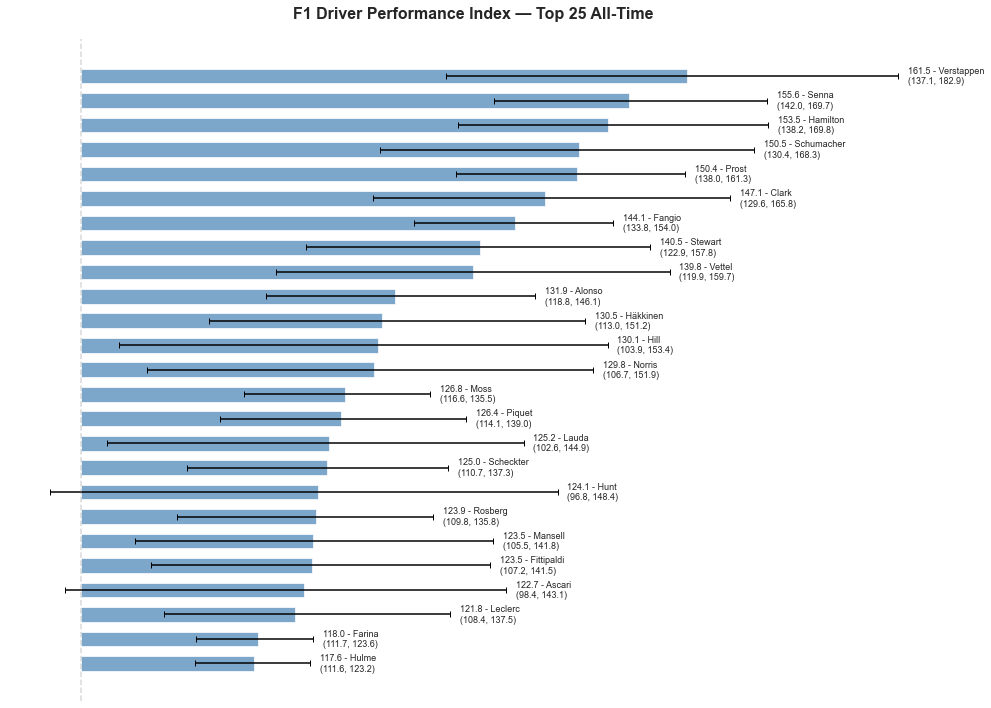

In [114]:
fig, ax = plt.subplots(figsize=(14, 10))
top25 = df_career.nlargest(25, 'career_dpi_bayesian').sort_values('career_dpi_bayesian')

# Plot bars
bars = ax.barh(range(len(top25)), top25['career_dpi_bayesian'] - 100, left=100, 
               color='steelblue', alpha=0.7, height=0.6)

# Plot error bars
ax.errorbar(
    top25['career_dpi_bayesian'].values, range(len(top25)),
    xerr=[top25['career_dpi_bayesian'].values - top25['ci_lower'].values,
          top25['ci_upper'].values - top25['career_dpi_bayesian'].values],
    fmt='none', color='black', capsize=3
)

# Add labels to the right: "DPI - Name\n(CI lower, CI upper)"
for i, (_, row) in enumerate(top25.iterrows()):
    label = f"{row['career_dpi_bayesian']:.1f} - {row['driver_last_name']}\n({row['ci_lower']:.1f}, {row['ci_upper']:.1f})"
    ax.text(row['ci_upper'] + 1, i, label, va='center', fontsize=9)

# Remove gridlines, axes, and ticks
ax.set_yticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.tick_params(left=False, bottom=False)
ax.set_xticks([])

# Reference line for average
ax.axvline(x=100, color='gray', linestyle='--', alpha=0.3)

ax.set_title('F1 Driver Performance Index — Top 25 All-Time', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

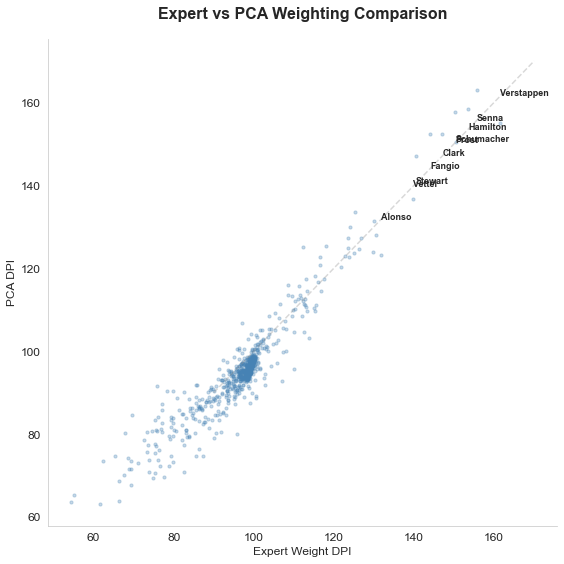

In [118]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(df_career['career_dpi_bayesian'],
           df_career.merge(
               df_indicators.groupby('driver_id')['dpi_pca'].mean().reset_index(),
               on='driver_id'
           )['dpi_pca'],
           alpha=0.3, s=10, color='steelblue')

# Label top drivers
for _, row in df_career.nlargest(10, 'career_dpi_bayesian').iterrows():
    ax.annotate(row['driver_last_name'],
                (row['career_dpi_bayesian'], row['career_dpi_bayesian']),
                fontsize=9, fontweight='bold')

# Diagonal reference line
ax.plot([90, 170], [90, 170], color='gray', linestyle='--', alpha=0.3)

# Remove gridlines
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlabel('Expert Weight DPI', fontsize=12)
ax.set_ylabel('PCA DPI', fontsize=12)
ax.set_title('Expert vs PCA Weighting Comparison', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## What the Scatter Tells Us

The strong linear alignment confirms that expert weights and PCA weights agree on the broad hierarchy — the top drivers cluster together in the upper right regardless of method. The drivers furthest off the diagonal tend to be drivers who benefited from dominant cars: they accumulated wins and podiums in superior machinery and score higher under PCA (which rewards raw performance) than under expert weights (which adjust for car via WAR and teammate H2H). This is exactly why we chose expert weights as the primary method.

## Conclusion

Drum roll please... we have our final awnser to who is the best driver in F1 one? its a resounding "WE DON'T KNOW".  

### Who ended up on top?
Overall it looks like based on our DPI, Max Verstappen sits at Number 1! However looking at our Bootstrap test, we cannot confidently say that he is the number one best driver of all time. If we look at the top Five drivers, Verstappen, Senna, Hamilton, Schumacher, or Prost, we can see that all 5 of their confidence intervals from the test overlap. Basically, we will need more data to narrow down their CIs, but as of right now we can say these are the top 5 drivers confidently, but we cannot confidently order them 1 through 5. 

### Biggest Surprise
I was also a bit surprised by the PCA. When I first started the notebook, I was expecting to use the PCA as the primary way to determine the weights. But as we saw earlier it acutally never really accounted for the differences in cars. This is what lead us to using the expert weights we defined at the beginning. I am curious to run the PCA weighted DPI through the Bootstrap test to see if we get smaller CIs, but we will make that update later. 

### Biggest Limitation
Our biggest limitation is obviously our data. I would like to gather a lot more data, either by scraping, logging it mannually, and eventually grabbing the data from the cars data source. I think having limited data before 1994 also made this project particuylarrly hard, because it makes it a lot harder to compare to the new generation of drivers. A lot has changed over the years, and its hard to determine if a driver from the 50s or 60s would be able to drive at a high level in a modern F1 car. 

### Looking to the Future
I would like to keep this as a living analysis. I would like to update it each year after the season is over as well as make updates to the weighting and methodologies if something new comes up. I would also like to add in new data and possibly new indicators as this grows. Also thank you for taking the time to read! if you have any comments, questions, or ideas for improvements feel free to reach out to me! 